# Importando as Bibliotecas

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Bibliotecas Importadas com Sucesso!!")

Bibliotecas Importadas com Sucesso!!


## Carregamento e Inspeção Inicial

In [2]:
dados = pd.read_csv("../data/olist_order_reviews_dataset.csv")
dados.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [3]:
print(f"Total de linhas -> {dados.shape[0]}")
print(f"Total de colunas -> {dados.shape[1]}")
print(f"\n===== Informações Dataset =====\n")
print(dados.info())

Total de linhas -> 99224
Total de colunas -> 7

===== Informações Dataset =====

<class 'pandas.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   review_id                99224 non-null  str  
 1   order_id                 99224 non-null  str  
 2   review_score             99224 non-null  int64
 3   review_comment_title     11568 non-null  str  
 4   review_comment_message   40977 non-null  str  
 5   review_creation_date     99224 non-null  str  
 6   review_answer_timestamp  99224 non-null  str  
dtypes: int64(1), str(6)
memory usage: 5.3 MB
None


## Qualidade dos Dados

In [4]:
print("===== Verificando Dados Nulos =====\n")
print(dados.isna().sum())

===== Verificando Dados Nulos =====

review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64


In [5]:
print(f"Total de dados duplicados : {dados.duplicated().sum()}")

Total de dados duplicados : 0


## Selecionando as colunas + Limpando Nulos

In [6]:
df = dados[["review_comment_message", "review_score"]].copy()
df.head()

,review_comment_message,review_score
0,NaN,4
1,NaN,5
2,NaN,5
3,Recebi bem antes do prazo estipulado.,5
4,Parabéns lojas lannister adorei comprar pela I...,5


In [7]:
print(df.isna().sum())

review_comment_message    58247
review_score                  0
dtype: int64


In [8]:
df = df.dropna()

print(f"Dados Nulos:")
print(df.isna().sum())

Dados Nulos:
review_comment_message    0
review_score              0
dtype: int64


In [9]:
print(f"Total de Linhas -> {df.shape[0]}")
print(f"Total de Colunas -> {df.shape[1]}")
print("\n===== Informações =====\n")
print(df.info())

Total de Linhas -> 40977
Total de Colunas -> 2

===== Informações =====

<class 'pandas.DataFrame'>
Index: 40977 entries, 3 to 99223
Data columns (total 2 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   review_comment_message  40977 non-null  str  
 1   review_score            40977 non-null  int64
dtypes: int64(1), str(1)
memory usage: 960.4 KB
None


## Analisando as avaliações

In [10]:
df["review_score"].value_counts().sort_index()

review_score
1     8745
2     2145
3     3557
4     5976
5    20554
Name: count, dtype: int64

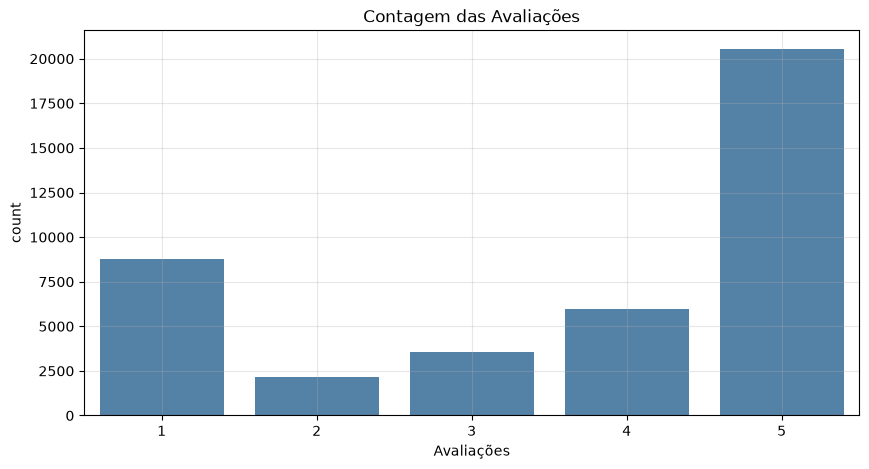

In [11]:
plt.figure(figsize=(10,5))

sns.countplot(data=df, x="review_score", color="steelblue")
plt.title("Contagem das Avaliações")
plt.xlabel("Avaliações")
plt.grid(alpha=0.3)
plt.show()

## Adicionando Regra - problema supervisionado

In [12]:
# iremos selecionar apenas score 1,2,4,5
df = df[df["review_score"] != 3]

In [13]:
# 1-2 -> negativo
# 4-5 -> positivo
sentimento = {
    1: "negativo",
    2: "negativo",
    4: "positivo",
    5: "positivo"
}

df["sentimento"] = df["review_score"].map(sentimento)

In [14]:
df["sentimento"].value_counts().sort_index()

sentimento
negativo    10890
positivo    26530
Name: count, dtype: int64

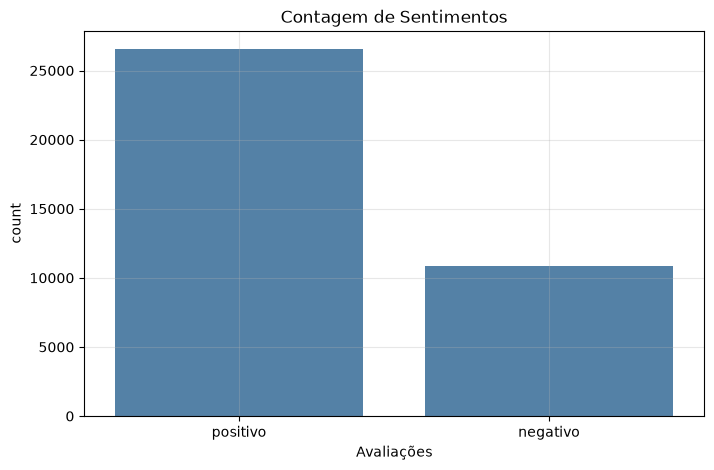

In [15]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="sentimento", color="steelblue")
plt.title("Contagem de Sentimentos")
plt.xlabel("Avaliações")
plt.grid(alpha=0.3)
plt.show()

## Salvando Dataset Final

In [17]:
df.to_csv("../data/dataset_tratado.csv")

print("Dados Salvos com Sucesso!!")

Dados Salvos com Sucesso!!
